In [16]:
import pandas as pd

df = pd.read_csv("../data/raw/train.csv")
img_meta_df = pd.read_csv("../data/processed/img_meta.csv")

df["fast_adopt"] = df["AdoptionSpeed"] <= 1

In [17]:
df_merge = df.merge(img_meta_df, on="PetID", how="left")

In [18]:
df_merge.groupby("fast_adopt")["img_0"].mean()
df_merge.groupby("fast_adopt")["img_1"].mean()

fast_adopt
False    0.680144
True     0.698348
Name: img_1, dtype: float64

### Insight: Image Feature Analysis

We analyzed CNN-extracted image features.

For example, feature `img_1` shows:

- Fast adopted pets: higher average value
- Slow adopted pets: lower average value

This suggests that visual features extracted from images are related to adoption speed.

Although individual features are not interpretable, the overall pattern indicates that image information contains useful signals.

In [19]:
for i in range(5):
    col = f"img_{i}"
    print(col)
    print(df_merge.groupby("fast_adopt")[col].mean())
    print("------")

img_0
fast_adopt
False    0.952658
True     0.619688
Name: img_0, dtype: float64
------
img_1
fast_adopt
False    0.680144
True     0.698348
Name: img_1, dtype: float64
------
img_2
fast_adopt
False    0.966404
True     0.616178
Name: img_2, dtype: float64
------
img_3
fast_adopt
False    1.757746
True     2.155896
Name: img_3, dtype: float64
------
img_4
fast_adopt
False    0.796174
True     0.586722
Name: img_4, dtype: float64
------


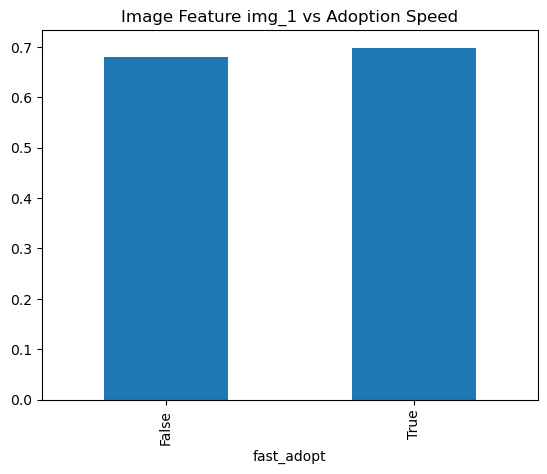

In [20]:
import matplotlib.pyplot as plt

df_merge.groupby("fast_adopt")["img_1"].mean().plot(kind="bar")
plt.title("Image Feature img_1 vs Adoption Speed")
plt.show()

In [21]:

df["fast_adopt"] = df["AdoptionSpeed"] <= 1

df["is_young"] = df["Age"] <= 6
df["is_free"] = df["Fee"] == 0
df["is_healthy"] = df["Health"] == 1

df["Type"] = df["Type"] - 1

In [23]:
df_merge = df.merge(img_meta_df, on="PetID", how="left")

In [24]:
image_cols = [f"img_{i}" for i in range(512)]

features = ["is_young", "is_free", "is_healthy", "Type", "PhotoAmt"]

X = df_merge[features + image_cols]
y = df_merge["fast_adopt"]

X = X.fillna(0)

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)


print("New Accuracy:", accuracy)

New Accuracy: 0.7602534178059354


In [27]:
print("Baseline Accuracy: 0.76")
print("With Image Features:", accuracy)

Baseline Accuracy: 0.76
With Image Features: 0.7602534178059354


In [28]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

X_base = df[["is_young", "is_free", "is_healthy", "Type", "PhotoAmt"]].fillna(0)
y_base = df["fast_adopt"]

scores_base = cross_val_score(model, X_base, y_base, cv=5, scoring="accuracy")
print("Baseline CV Accuracy:", scores_base.mean())


X_full = df_merge[["is_young", "is_free", "is_healthy", "Type", "PhotoAmt"] + image_cols].fillna(0)
y_full = df_merge["fast_adopt"]

scores_full = cross_val_score(model, X_full, y_full, cv=5, scoring="accuracy")
print("With Image CV Accuracy:", scores_full.mean())

Baseline CV Accuracy: 0.766557720707881
With Image CV Accuracy: 0.766557720707881
